In [1]:
import torch
from ultralytics import YOLO
from IPython.display import display, Image
from IPython import display

In [2]:
import os 
%cd datasets

/home/ilham/playground/yolov8/datasets


/home/ilham/.local/lib/python3.12/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="yewVIVxq90NeKDrRpT6E")
project = rf.workspace("satasia").project("pest-detection-pyjsb")
version = project.version(8)
# dataset = version.download("yolov8")

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
# Load a COCO-pretrained YOLOv8n model
model = YOLO("yolov8s.pt")

# Display model information (optional)
model.info()

# Train the model on custom dataset
results = model.train(data="/home/ilham/playground/yolov8/datasets/Pest-Detection-8/data.yaml", epochs=100, imgsz=640, show_conf=False, patience=10, batch=16)

100%|██████████████████████████████████████████████████████████████████████████████| 21.5M/21.5M [00:00<00:00, 37.1MB/s]
/home/ilham/.local/lib/python3.12/site-packages/ultralytics/nn/tasks.py:567: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an 

Freezing layer 'model.22.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks with YOLOv8n...
/home/ilham/.local/lib/python3.12/site-packages/ultralytics/nn/tasks.py:567: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on Gi

lr/pg0,█████▇▇▇▇▇▇▇▆▆▆▆▅▅▅▅▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▂▁▁▁▁
lr/pg1,▁▅███▇▇▇▇▇▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▁▁
lr/pg2,▁▅███▇▇▇▇▇▇▆▆▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▁
metrics/mAP50(B),▂▁▁▁▄▅▅▅▆▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇█▇▇▇▇▇███████▇▇█
metrics/mAP50-95(B),▂▁▂▁▃▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇█▇▇▇████████▇▇█
metrics/precision(B),▁▁▄▅▅▅▆▅▅▆▆▅▆▇▆▅▅▇▇▆▇▅▆▆▇█▇▇▇▇▇███▇███▇█
metrics/recall(B),▁▁▃▇▄▄▇▇▄▇██▇▇▇█▇▇██▇▇▇▇▇█▇███▇▇▇█▇▇▇▇▇▇
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
train/box_loss,█▆▇█▆▆▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁


In [3]:
model = YOLO("runs/detect/train13/weights/last.pt")
model.train(resume=True)

New https://pypi.org/project/ultralytics/8.3.70 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.65  Python-3.9.21 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: task=detect, mode=train, model=runs\detect\train13\weights\last.pt, data=C:\Users\user\machinelearning\dataset\vannamei+mb\data.yaml, epochs=100, time=None, patience=10, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train13, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=runs\detect\train13\weights\last.pt, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=Fal

train: Scanning C:\Users\user\machinelearning\dataset\vannamei+mb\train\labels.cache... 1797 images, 6 backgrounds, 0 c


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


C:\Users\user\anaconda3\envs\yolov8_env\lib\site-packages\albumentations\__init__.py:24: UserWarning: A new version of Albumentations is available: '2.0.2' (you have '2.0.0'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
C:\Users\user\anaconda3\envs\yolov8_env\lib\site-packages\ultralytics\data\augment.py:1853: UserWarning: Argument 'quality_lower' is not valid and will be ignored.
  A.ImageCompression(quality_lower=75, p=0.0),
val: Scanning C:\Users\user\machinelearning\dataset\vannamei+mb\valid\labels.cache... 72 images, 1 backgrounds, 0 corru


Plotting labels to runs\detect\train13\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001667, momentum=0.9) with parameter groups 77 weight(decay=0.0), 84 weight(decay=0.0005), 83 bias(decay=0.0)
Resuming training runs\detect\train13\weights\last.pt from epoch 43 to 100 total epochs
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to runs\detect\train13
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

                   all         72       4107      0.798      0.777      0.804      0.361
EarlyStopping: Training stopped early as no improvement observed in last 10 epochs. Best results observed at epoch 44, best model saved as best.pt.
To update EarlyStopping(patience=10) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



12 epochs completed in 0.804 hours.
Optimizer stripped from runs\detect\train13\weights\last.pt, 52.0MB
Optimizer stripped from runs\detect\train13\weights\best.pt, 52.0MB

Validating runs\detect\train13\weights\best.pt...
Ultralytics 8.3.65  Python-3.9.21 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
Model summary (fused): 218 layers, 25,840,918 parameters, 0 gradients, 78.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:05<0


                   all         72       4107      0.788      0.777      0.806       0.37
               shrimps         71       4107      0.788      0.777      0.806       0.37
Speed: 0.9ms preprocess, 50.4ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to runs\detect\train13


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000026AAC04A700>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480

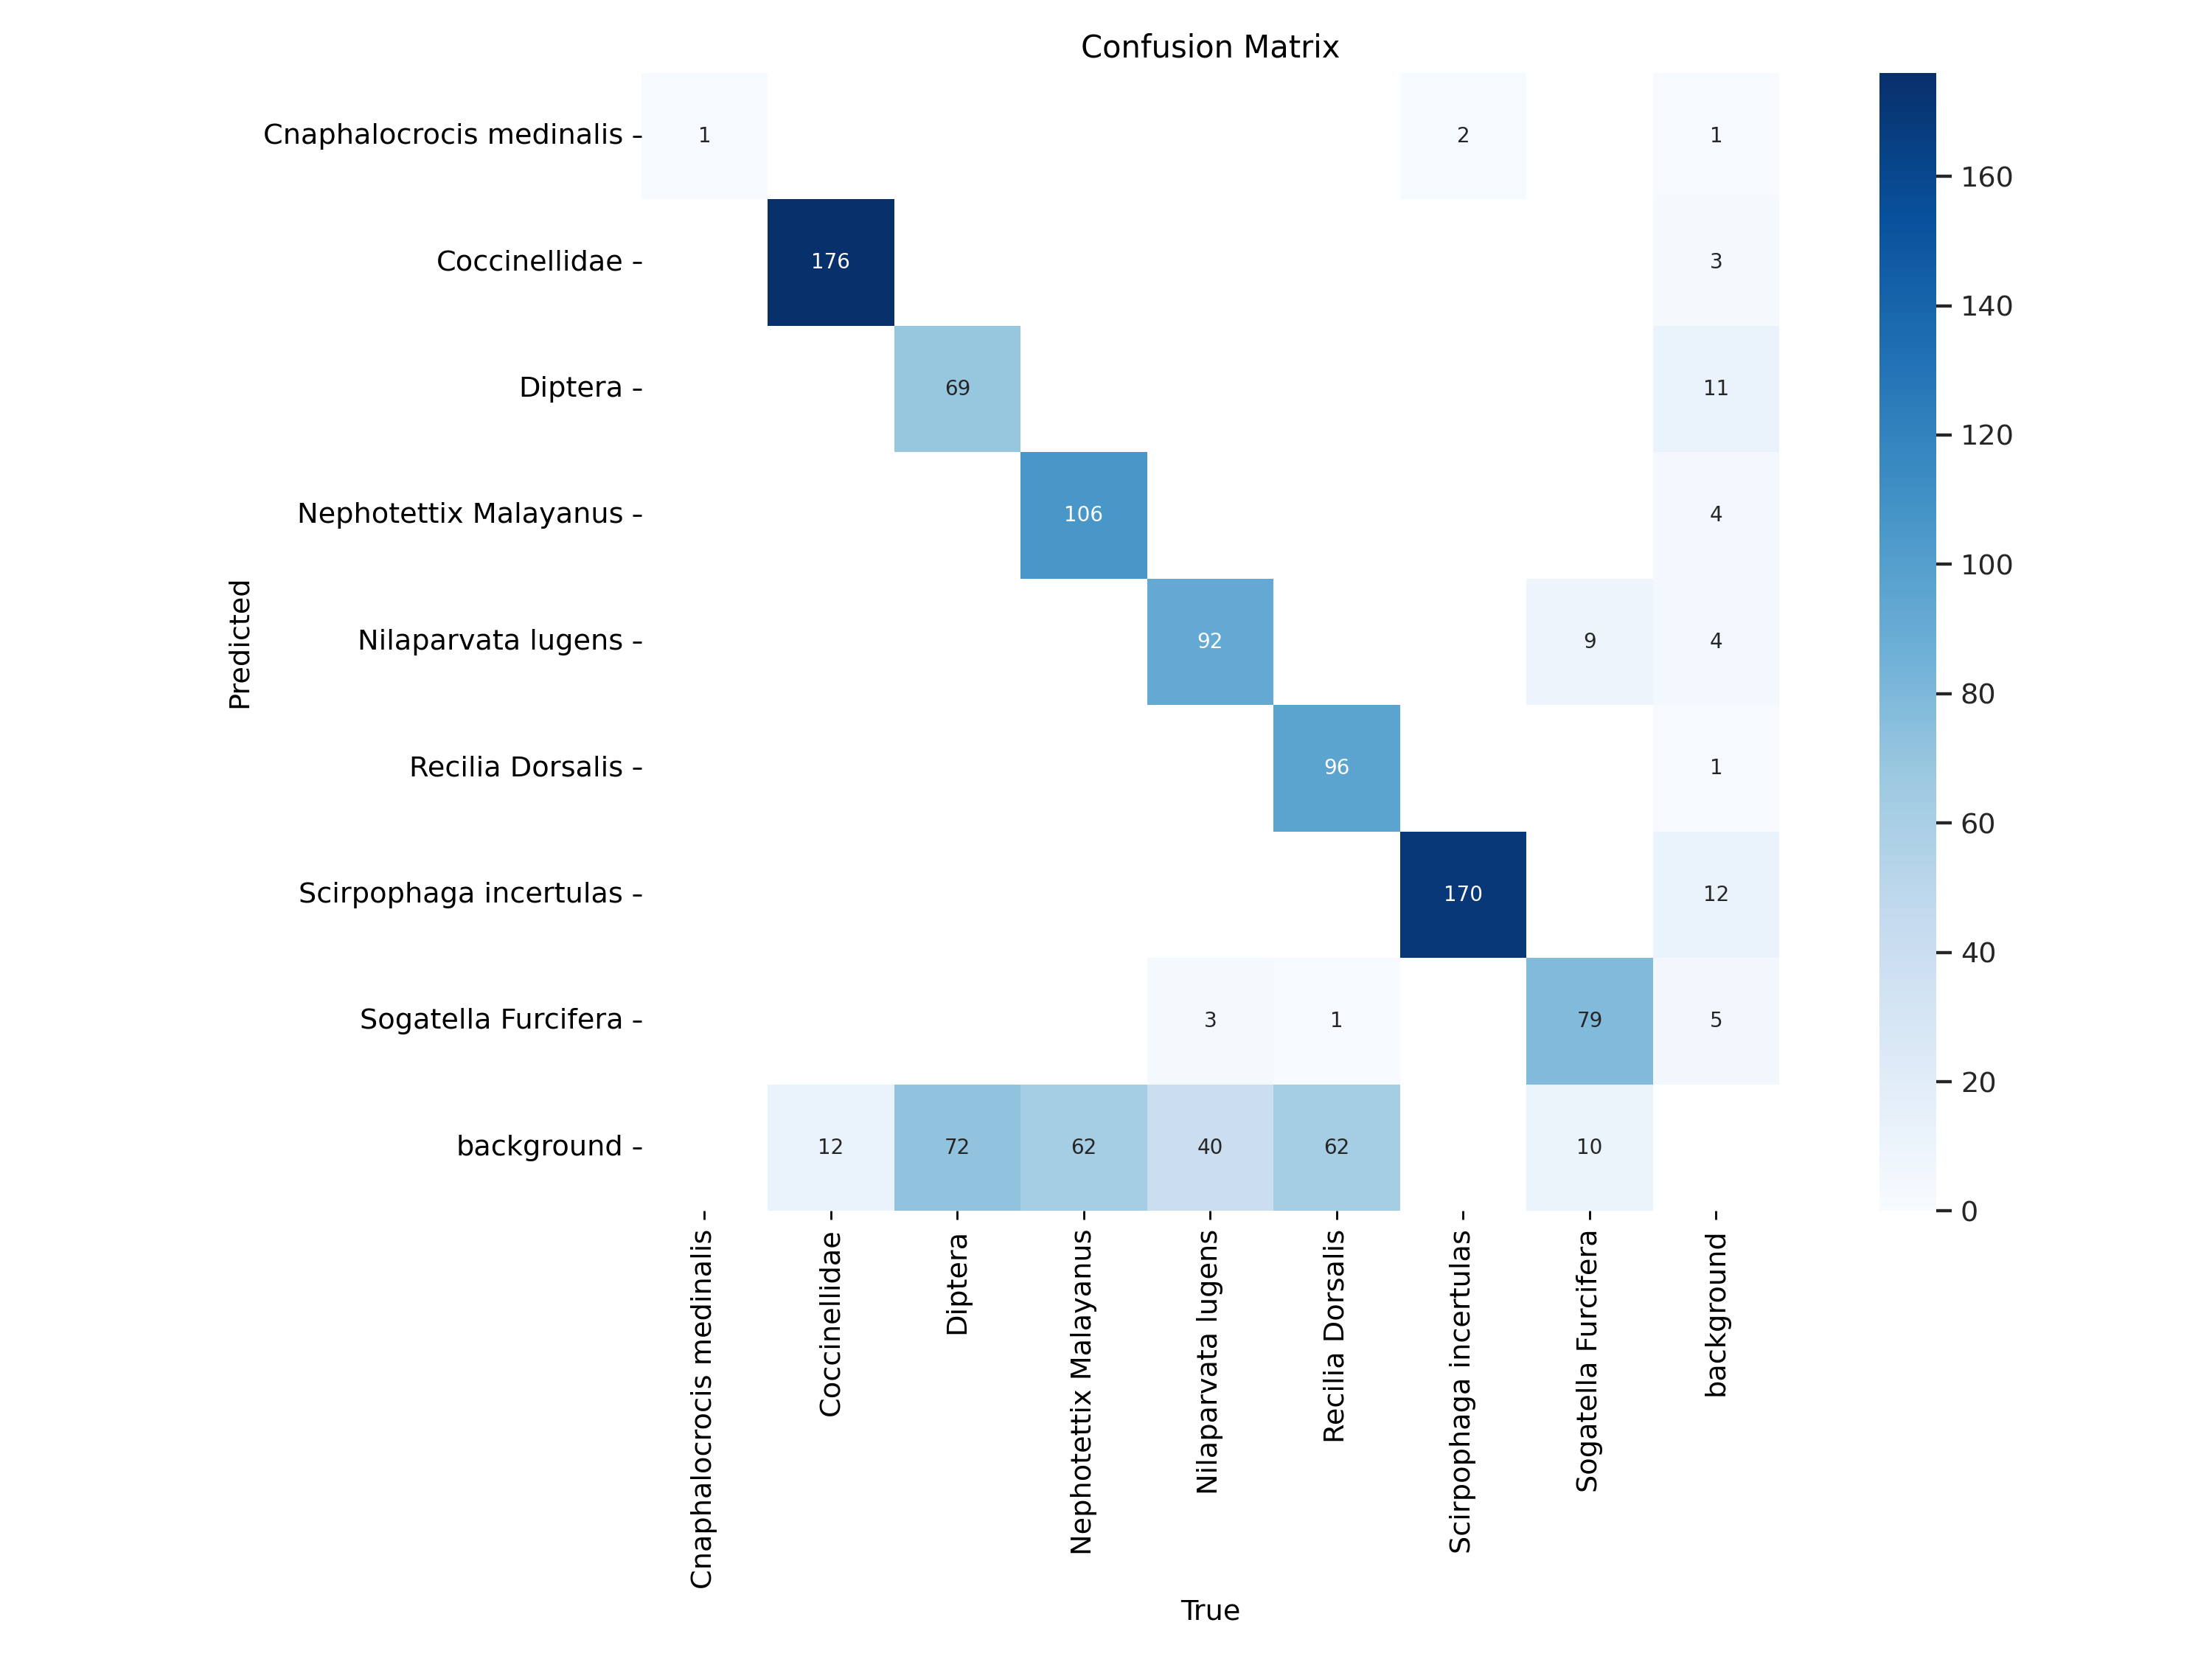

In [3]:
Image(filename=f'runs/detect/train18/confusion_matrix.png', width=600)

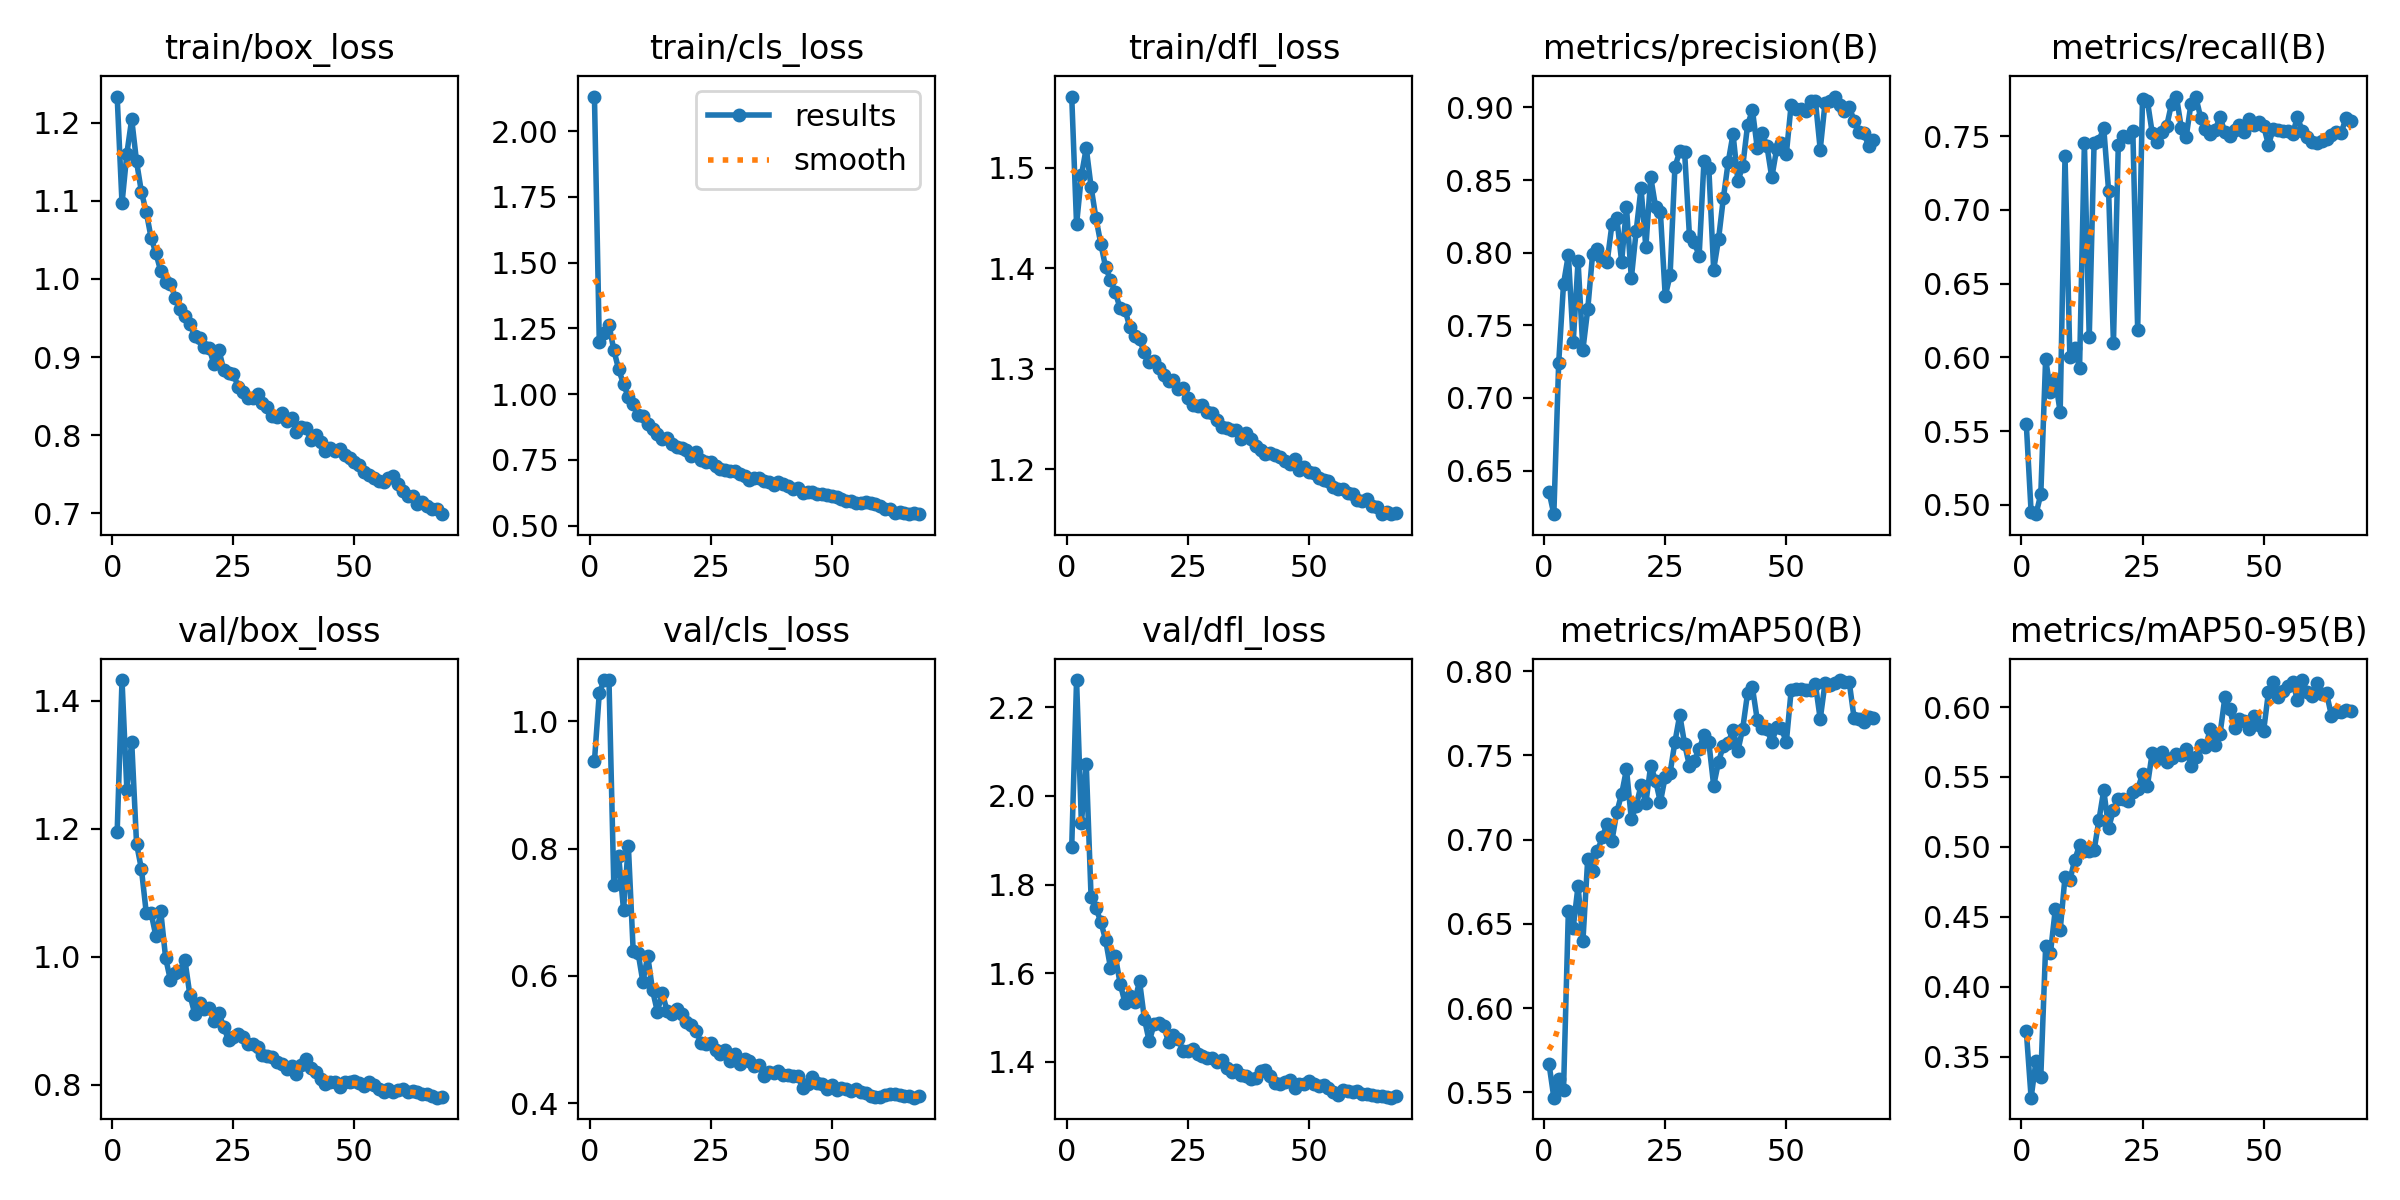

In [4]:
Image(filename=f'runs/detect/train18/results.png', width=600)


image 1/1 /home/ilham/playground/yolov8/datasets/image-test/PSA5M1A/iScout_20250228_0707_07214BBC_PIC_43_CAM_1.xml.jpg: 480x640 1 Cnaphalocrocis medinalis, 48.4ms
Speed: 4.3ms preprocess, 48.4ms inference, 5.3ms postprocess per image at shape (1, 3, 480, 640)


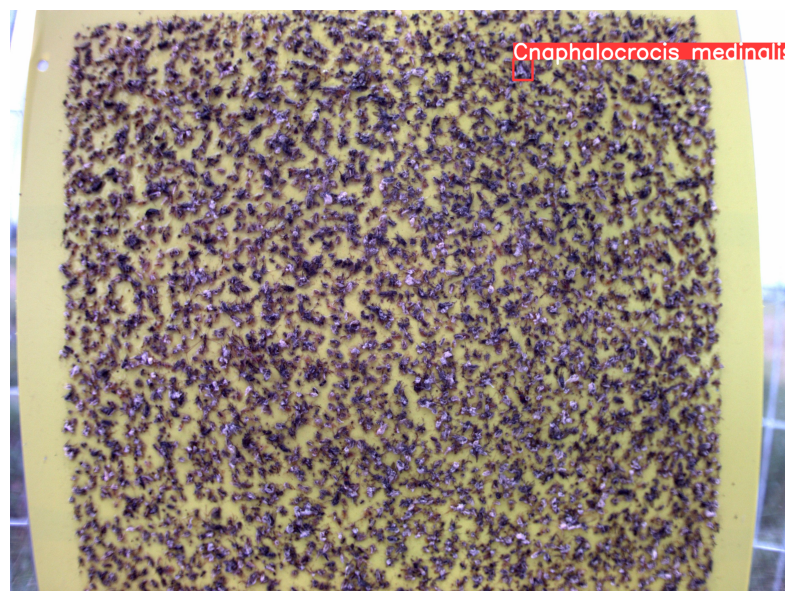

Detected Pest Count: 1
JSON will be saved at: inference_result/PSA5M1A/iScout_20250228_0707_07214BBC_PIC_43_CAM_1.xml.json
Image will be saved at: inference_result/PSA5M1A/iScout_20250228_0707_07214BBC_PIC_43_CAM_1.xml_detections.jpg
✅ Bounding boxes saved to inference_result/PSA5M1A/iScout_20250228_0707_07214BBC_PIC_43_CAM_1.xml.json
✅ Image with detections saved to inference_result/PSA5M1A/iScout_20250228_0707_07214BBC_PIC_43_CAM_1.xml_detections.jpg


In [17]:
from ultralytics import YOLO
import cv2
import json
import uuid
import os
import matplotlib.pyplot as plt

# Load the trained model
model = YOLO("runs/detect/train18/weights/best.pt")  # Adjust path if needed

# Load an image
img_path = "datasets/image-test/PSA5M1A/iScout_20250228_0707_07214BBC_PIC_43_CAM_1.xml.jpg"  # Change to your image path
results = model(img_path, conf=0.1, iou=0.4)  # Run inference

# Generate annotated image
annotated_img = results[0].plot(conf=False)  # This returns an image with detections

# Convert from BGR to RGB for correct color representation
annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

# Display the image in JupyterLab
plt.figure(figsize=(10, 10))
plt.imshow(annotated_img_rgb)
plt.axis("off")  # Hide axes
plt.show()

# Extract bounding boxes
detections = results[0].boxes  # List of detected boxes

# Get number of detected pests
counts = len(detections)
print(f"Detected Pest Count: {counts}")

# Extract bounding boxes and format output
predictions = []
for result in results:
    for box in result.boxes:
        x_center, y_center, width, height = box.xywh[0].tolist()
        confidence = float(box.conf[0])
        class_id = int(box.cls[0])
        class_name = model.names[class_id]  # Get class name

        predictions.append({
            "x": x_center,
            "y": y_center,
            "width": width,
            "height": height,
            "confidence": confidence,
            "class": class_name,
            "class_id": class_id,
            "detection_id": str(uuid.uuid4())  # Generate unique ID
        })

# Convert to JSON format
output = {"predictions": predictions}
json_output = json.dumps(output, indent=2)

# Extract image filename (without extension)
image_filename = os.path.splitext(os.path.basename(img_path))[0]

# Define the output directory
output_dir = "inference_result/PSA5M1A"  # Change this to your preferred folder name

# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)  # Creates the directory if it doesn't exist

# Define full paths for saving
json_filename = os.path.join(output_dir, f"{image_filename}.json")
save_path = os.path.join(output_dir, f"{image_filename}_detections.jpg")

# Debugging print statements
print(f"JSON will be saved at: {json_filename}")
print(f"Image will be saved at: {save_path}")

# Save JSON file
try:
    with open(json_filename, "w") as f:
        f.write(json_output)
    print(f"✅ Bounding boxes saved to {json_filename}")
except Exception as e:
    print(f"❌ Error saving JSON: {e}")

# Save annotated image
try:
    success = cv2.imwrite(save_path, annotated_img)
    if success:
        print(f"✅ Image with detections saved to {save_path}")
    else:
        print(f"❌ Failed to save image.")
except Exception as e:
    print(f"❌ Error saving image: {e}")


In [6]:
%matplotlib inline

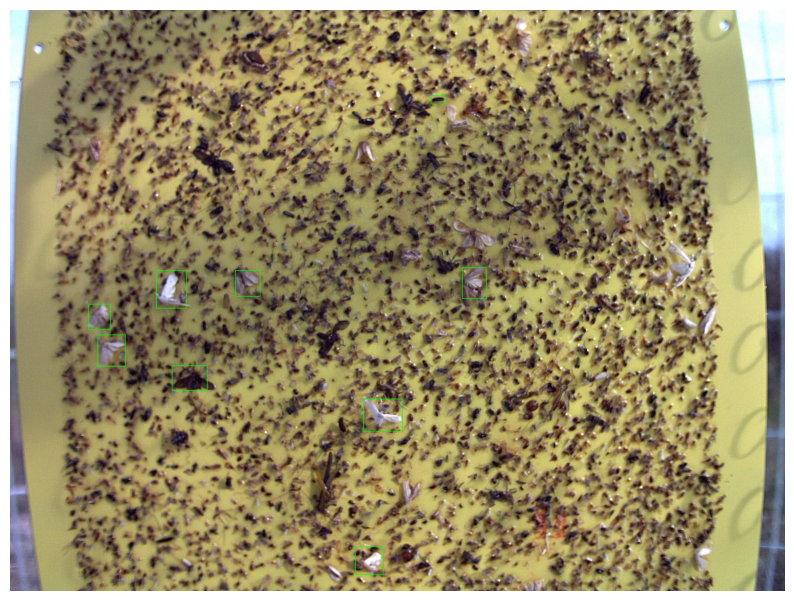

In [7]:
import numpy as np

# Read image
img = cv2.imread(img_path)

# Loop through detections
for box in detections:
    x1, y1, x2, y2 = map(int, box.xyxy[0])  # Get bounding box coordinates
    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)  # Draw box
    # cv2.putText(img, "Shrimp", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

# Convert BGR to RGB for display
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Show image
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis("off")
plt.show()

In [4]:
from ultralytics import YOLO

# Load the YOLO8 model
model = YOLO("runs/detect/train16/weights/best.pt")

# Export the model to TFLite format
model.export(format="tflite")  # creates 'yolo11n_float32.tflite'

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
Ultralytics YOLOv8.0.196 🚀 Python-3.12.3 torch-2.5.1+cu124 CPU (AMD Ryzen 5 8645HS w/ Radeon 760M Graphics)
Model summary (fused): 168 layers, 3

ModuleNotFoundError: No module named 'tensorflow'

In [4]:
project.version(8).deploy(model_type="yolov8", model_path=f"runs/detect/train18")

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


View the status of your deployment at: https://app.roboflow.com/satasia/pest-detection-pyjsb/8
Share your model with the world at: https://universe.roboflow.com/satasia/pest-detection-pyjsb/model/8


In [12]:
import glob

for image_path in glob.glob(f'runs/detect/val3/*.jpg'):
    Image(filename=image_path, height=600)
    print("\n")
            

In [13]:
best_model = YOLO(f'runs/detect/train8/weights/best.pt')

best_model.predict(data=r"C:\Users\user\machinelearning\dataset\marketboy\data.yaml")

WARNING  'source' is missing. Using 'source=C:\Users\user\anaconda3\envs\yolov8_env\Lib\site-packages\ultralytics\assets'.

image 1/2 C:\Users\user\anaconda3\envs\yolov8_env\Lib\site-packages\ultralytics\assets\bus.jpg: 640x480 264 shrimpss, 61.9ms
image 2/2 C:\Users\user\anaconda3\envs\yolov8_env\Lib\site-packages\ultralytics\assets\zidane.jpg: 384x640 291 shrimpss, 102.7ms
Speed: 3.5ms preprocess, 82.3ms inference, 2.7ms postprocess per image at shape (1, 3, 384, 640)


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'shrimps'}
 obb: None
 orig_img: array([[[119, 146, 172],
         [121, 148, 174],
         [122, 152, 177],
         ...,
         [161, 171, 188],
         [160, 170, 187],
         [160, 170, 187]],
 
        [[120, 147, 173],
         [122, 149, 175],
         [123, 153, 178],
         ...,
         [161, 171, 188],
         [160, 170, 187],
         [160, 170, 187]],
 
        [[123, 150, 176],
         [124, 151, 177],
         [125, 155, 180],
         ...,
         [161, 171, 188],
         [160, 170, 187],
         [160, 170, 187]],
 
        ...,
 
        [[183, 182, 186],
         [179, 178, 182],
         [180, 179, 183],
         ...,
         [121, 111, 117],
         [113, 103, 109],
         [115, 105, 111]],
 
        [[165, 164, 168],
         [173, 172, 176],
         [187, 186, 190],
         ...,
         [102,  9

In [14]:
metrics = model.val()  # no arguments needed, dataset and settings remembered
metrics.box.map  # map50-95
metrics.box.map50  # map50
metrics.box.map75  # map75
metrics.box.maps

Ultralytics 8.3.65  Python-3.9.21 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
Model summary (fused): 218 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs


val: Scanning C:\Users\user\machinelearning\dataset\marketboy\valid\labels.cache... 7 images, 0 backgrounds, 0 corrupt:

WARNING  Box and segment counts should be equal, but got len(segments) = 469, len(boxes) = 820. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:04<0


                   all          7        820      0.213      0.307      0.132     0.0411
Speed: 9.6ms preprocess, 81.5ms inference, 0.0ms loss, 15.4ms postprocess per image
Results saved to runs\detect\train82


array([   0.041072])